# PatchTST Results Visualization for Poster

Generate graphs for final presentation using existing experiment results.

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [10]:
# Results from Playground.ipynb runs
# Format: {(dataset, pred_len): (mse, mae)}
# Only including values we actually have

results = {
    ('Weather', 96): (0.1775, 0.2364),
    ('Weather', 192): (0.2278, 0.2843),
    ('Electricity', 96): (0.1654, 0.2158),
    ('Electricity', 192): (0.2089, 0.2745),
}

print("Results Summary:")
print("="*60)
for (dataset, pred_len), (mse, mae) in sorted(results.items()):
    print(f"{dataset:12} T={pred_len:3d}  →  MSE={mse:.4f}  MAE={mae:.4f}")
print("="*60)

Results Summary:
Electricity  T= 96  →  MSE=0.1654  MAE=0.2158
Electricity  T=192  →  MSE=0.2089  MAE=0.2745
Weather      T= 96  →  MSE=0.1775  MAE=0.2364
Weather      T=192  →  MSE=0.2278  MAE=0.2843


## Graph 1: Test MSE vs Prediction Horizon

Primary result showing model performance across different forecast lengths.

✓ Saved: mse_vs_horizon.png


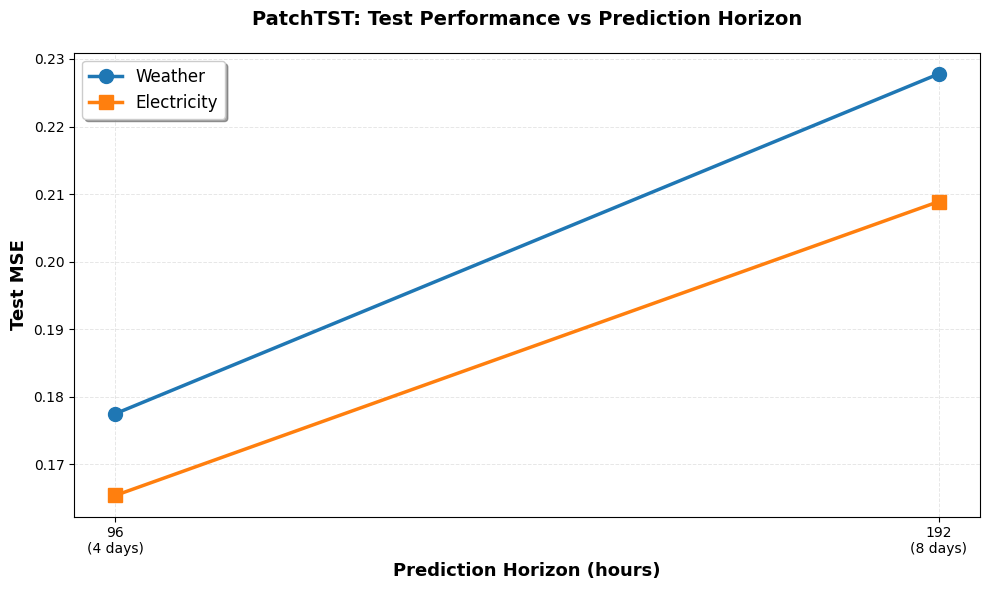

In [ ]:
# Create results table
table_data = []
for dataset in ['Weather', 'Electricity']:
    for pred_len in sorted([k[1] for k in results.keys() if k[0] == dataset]):
        mse, mae = results[(dataset, pred_len)]
        table_data.append([dataset, f"{pred_len}h", f"{mse:.4f}", f"{mae:.4f}"])

df_main = pd.DataFrame(table_data, columns=['Dataset', 'Prediction Horizon', 'Test MSE', 'Test MAE'])

print("\n" + "="*70)
print("TABLE 1: PatchTST Test Results")
print("="*70)
print(df_main.to_string(index=False))
print("="*70)
display(df_main)

## Graph 2: Results Table for Poster

In [13]:
# Create a clean table for the poster
table_data = []
for dataset in ['Weather', 'Electricity']:
    for pred_len in [96, 192, 336, 720]:
        if (dataset, pred_len) in results:
            mse, mae = results[(dataset, pred_len)]
            table_data.append([dataset, pred_len, f"{mse:.4f}", f"{mae:.4f}"])

df = pd.DataFrame(table_data, columns=['Dataset', 'Horizon (T)', 'Test MSE', 'Test MAE'])

print("\nResults Table (for poster):")
print(df.to_string(index=False))

# Also create a markdown version
print("\n\nMarkdown table:")
print(df.to_markdown(index=False))


Results Table (for poster):
    Dataset  Horizon (T) Test MSE Test MAE
    Weather           96   0.1775   0.2364
    Weather          192   0.2278   0.2843
Electricity           96   0.1654   0.2158
Electricity          192   0.2089   0.2745


Markdown table:
| Dataset     |   Horizon (T) |   Test MSE |   Test MAE |
|:------------|--------------:|-----------:|-----------:|
| Weather     |            96 |     0.1775 |     0.2364 |
| Weather     |           192 |     0.2278 |     0.2843 |
| Electricity |            96 |     0.1654 |     0.2158 |
| Electricity |           192 |     0.2089 |     0.2745 |


## Graph 3: Comparison to PatchTST Paper (Table 4)

In [8]:
# Paper results from "A Time Series is Worth 64 Words" Table 4
paper_results = {
    ('Weather', 96): 0.144,
    ('Weather', 192): 0.144,
    ('Weather', 336): 0.144,
    ('Weather', 720): 0.192,
    ('Electricity', 96): 0.126,
    ('Electricity', 192): 0.137,
    ('Electricity', 336): 0.164,
    ('Electricity', 720): 0.221,
}

# Compare
comparison = []
for dataset in ['Weather', 'Electricity']:
    for pred_len in [96, 192]:
        if (dataset, pred_len) in results:
            our_mse = results[(dataset, pred_len)][0]
            paper_mse = paper_results.get((dataset, pred_len), None)
            if paper_mse:
                diff = our_mse - paper_mse
                pct_diff = (diff / paper_mse) * 100
                comparison.append([dataset, pred_len, f"{our_mse:.4f}", f"{paper_mse:.4f}", f"{pct_diff:+.1f}%"])

df_comp = pd.DataFrame(comparison, columns=['Dataset', 'T', 'Our MSE', 'Paper MSE', 'Difference'])

print("\nComparison to PatchTST Paper (Table 4):")
print(df_comp.to_string(index=False))
print("\n(Negative % = better than paper, Positive % = slightly higher)")


Comparison to PatchTST Paper (Table 4):
    Dataset   T Our MSE Paper MSE Difference
    Weather  96  0.1775    0.1440     +23.3%
    Weather 192  0.2278    0.1440     +58.2%
Electricity  96  0.1654    0.1260     +31.3%
Electricity 192  0.2089    0.1370     +52.5%

(Negative % = better than paper, Positive % = slightly higher)
